In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
#Import bertopic
from bertopic import BERTopic

In [2]:
# Import metadata
df = pd.read_csv("../data/document_data_clean_filtered.csv")

In [20]:
#Import text
docs_downloaded = os.listdir("../data/corpus_eucalyptus_only")
docs_downloaded = list(set([x.split('.')[0] for x in docs_downloaded]))

doc_text = []
for doc in docs_downloaded:
    with open(f"../data/corpus_eucalyptus_only/{doc}.txt", "r", encoding='utf-8') as f:
        doc_text.append(f.read().strip())

In [21]:
not_empty_docs = [x for x in doc_text if x.strip() != "" and "span" not in x.lower()]

## 1) Topic modelling

In [23]:
topic_model = BERTopic(language="multilingual")
topics, probs = topic_model.fit_transform(not_empty_docs)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4023.23it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
topic_model.get_topic(13)

[('panama', np.float64(0.09557362344737513)),
 ('goudron', np.float64(0.09202511133733045)),
 ('naphtol', np.float64(0.07755385573973633)),
 ('savon', np.float64(0.06328625216329246)),
 ('ichthyol', np.float64(0.05145469923625804)),
 ('boriqué', np.float64(0.05110458133336077)),
 ('sublimé', np.float64(0.04444342584511825)),
 ('cutanées', np.float64(0.04367152276394492)),
 ('solvéol', np.float64(0.04318958444098102)),
 ('maladies', np.float64(0.042872918855554734))]

In [25]:
topic_document_info_df = topic_model.get_document_info(not_empty_docs)
topic_document_info_df[topic_document_info_df["Representative_document"] == True]

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
7,pendant mon séjour dans cette localité et auss...,88,88_apiculteurs_jardin_jardins_vous,"[apiculteurs, jardin, jardins, vous, on, nous,...",[pendant mon séjour dans cette localité et aus...,apiculteurs - jardin - jardins - vous - on - n...,0.955081,True
13,"Brandi- et belle villa à Cannes, boulevard du ...",58,58_villa_salon_étage_salle,"[villa, salon, étage, salle, office, cuisine, ...","[Brandi- et belle villa à Cannes, boulevard du...",villa - salon - étage - salle - office - cuisi...,1.000000,True
29,ouest de nos vaisseaux m’offrirent un grand no...,7,7_mètres_pieds_hauteur_qui,"[mètres, pieds, hauteur, qui, un, de, des, plu...",[« Une très curieuse découverte vient d'être f...,mètres - pieds - hauteur - qui - un - de - des...,0.260084,True
30,"Codman, Ogden Esq., ang., v. Francesca, chem. ...",23,23_mme_fr_fam_ang,"[mme, fr, fam, ang, xxi, mrs, mr, mlle, course...",[Arrivés à l’Hôtel Beau-Rivage : Princesse de ...,mme - fr - fam - ang - xxi - mrs - mr - mlle -...,0.873291,True
35,"— de chaux (ou craie prép.), 40 gr. — de lithi...",93,93_flacon_gr_litre_kil,"[flacon, gr, litre, kil, boîte, 125, le, 100, ...","[— de chaux (ou craie prép.), 40 gr. — de lith...",flacon - gr - litre - kil - boîte - 125 - le -...,1.000000,True
...,...,...,...,...,...,...,...,...
6139,COMITÉ D’AGRICULTURE ET DE COMMERCE PRÉSIDENCE...,92,92_te_société_1876_hia,"[te, société, 1876, hia, ua, exposition, no, p...",[XII. — SOCIÉTÉ CLIMATOLOGIQUE ALGÉRIENNE Séan...,te - société - 1876 - hia - ua - exposition - ...,0.999203,True
6148,"jusqu’à mentir pour ne pas le perdre, elle si ...",63,63_elle_était_avait_sa,"[elle, était, avait, sa, il, lui, albrègue, la...","[jusqu’à mentir pour ne pas le perdre, elle si...",elle - était - avait - sa - il - lui - albrègu...,1.000000,True
6271,"économistes. On en voulait manger, on en mange...",5,5_je_vous_elle_un,"[je, vous, elle, un, ne, il, se, le, tu, que]","[les jujubiers, on peut apercevoir le bout des...",je - vous - elle - un - ne - il - se - le - tu...,1.000000,True
6278,Établissement d’horticulture et pépinière DE V...,41,41_gré_veuve_rossier_vente,"[gré, veuve, rossier, vente, catalpas, erables...","[Pour l’année 1884-85, la maison veuve ROSSIER...",gré - veuve - rossier - vente - catalpas - era...,1.000000,True


### 2) Distributions

<Axes: xlabel='date_clean', ylabel='Density'>

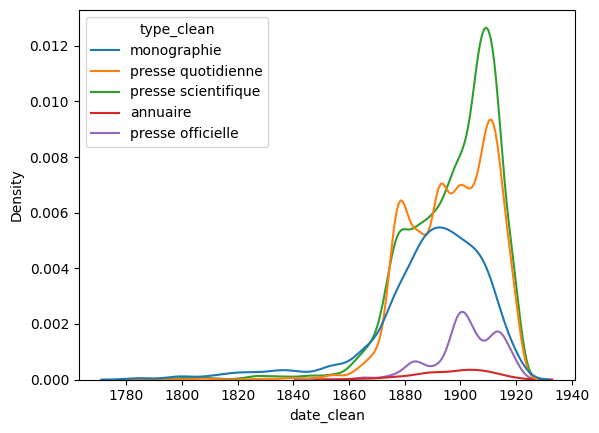

In [ ]:
sns.kdeplot(df, x="date_clean", hue="type_clean")

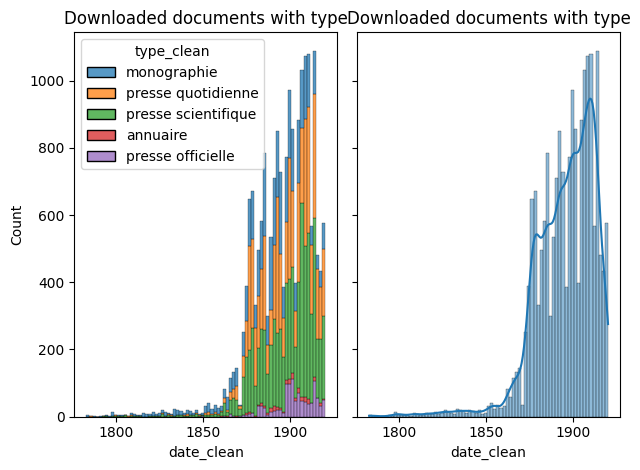

In [ ]:
fig, ax = plt.subplots(1, 2, sharey=True)
plt.sca(ax[0])
plt.title("Downloaded documents with type")
sns.histplot(df, x="date_clean", hue="type_clean", multiple="stack")
plt.sca(ax[1])
plt.title("Downloaded documents with type")
sns.histplot(df, x="date_clean", kde=True)
plt.tight_layout()
plt.show()

In [ ]:
df["type_clean"].value_counts()